# F — Statistical validation and error analysis

Reads artifacts from Group F. **Does not recompute GOP**.

| File | Content |
| --- | --- |
| `outputs/F/f_predictions.csv` | Locked test scores (C1/C8/C9/B4_OLS/E*) |
| `outputs/F/f_results.json` | F1 bootstrap + paired Δ + multi-seed; F2 taxonomy |
| `outputs/F/f2_top_errors.csv` | Largest residuals for C8 / E16 |

```text
python scripts/run_experiment.py --config configs/f_validation.yaml
python scripts/run_experiment.py --config configs/f_validation.yaml --skip-multiseed
```


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "outputs" / "F" / "f_results.json").is_file():
    if (ROOT / "GOP-Empirical-Study" / "outputs" / "F" / "f_results.json").is_file():
        ROOT = ROOT / "GOP-Empirical-Study"
    elif (ROOT.parent / "outputs" / "F" / "f_results.json").is_file():
        ROOT = ROOT.parent

OUT = ROOT / "outputs" / "F"
results = json.loads((OUT / "f_results.json").read_text(encoding="utf-8"))
f1 = results["F1"]
f2 = results["F2"]
print("n_test", results["protocol"]["n_test"], "n_boot", results["protocol"]["n_bootstrap"])
print("multiseed skipped", f1["multiseed"].get("skipped"))
for mid, block in f1["models"].items():
    p = block["pcc"]
    print(f"{mid:8s} PCC {p['point']:.3f} CI [{p['ci_low']:.3f}, {p['ci_high']:.3f}]")


n_test 47369 n_boot 1000
multiseed skipped False
C1       PCC 0.342 CI [0.333, 0.351]
C8       PCC 0.463 CI [0.453, 0.473]
C9       PCC 0.430 CI [0.420, 0.440]
B4_OLS   PCC 0.351 CI [0.342, 0.361]
E2       PCC 0.510 CI [0.495, 0.523]
E7       PCC 0.446 CI [0.433, 0.460]
E8       PCC 0.530 CI [0.516, 0.543]
E10      PCC 0.639 CI [0.626, 0.651]
E12      PCC 0.624 CI [0.611, 0.637]
E14      PCC 0.625 CI [0.612, 0.637]
E16      PCC 0.671 CI [0.660, 0.683]
E18      PCC 0.653 CI [0.639, 0.664]


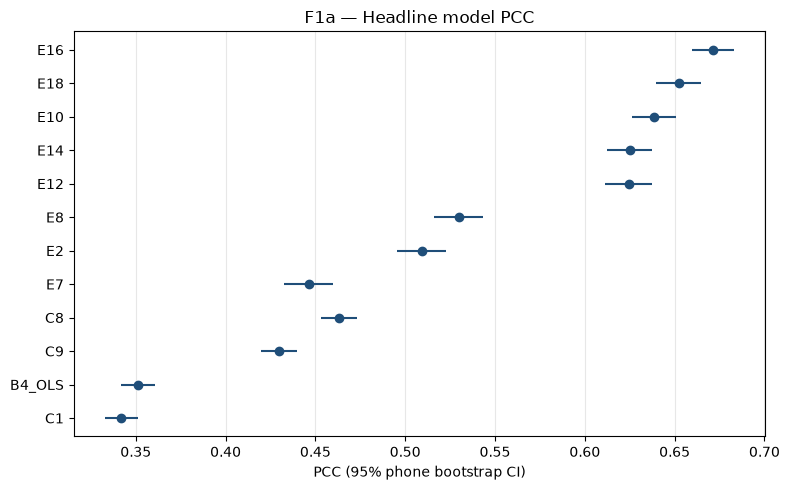

In [2]:
rows = []
for mid, block in f1["models"].items():
    p = block["pcc"]
    rows.append({"model": mid, "pcc": p["point"], "lo": p["ci_low"], "hi": p["ci_high"]})
ci = pd.DataFrame(rows)
order = ["C1", "B4_OLS", "C9", "C8", "E7", "E2", "E8", "E12", "E14", "E10", "E18", "E16"]
ci["model"] = pd.Categorical(ci["model"], categories=order, ordered=True)
ci = ci.sort_values("model")

fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(ci))
ax.errorbar(ci["pcc"], y, xerr=[ci["pcc"] - ci["lo"], ci["hi"] - ci["pcc"]], fmt="o", color="#1f4e79")
ax.set_yticks(list(y))
ax.set_yticklabels(ci["model"])
ax.set_xlabel("PCC (95% phone bootstrap CI)")
ax.set_title("F1a — Headline model PCC")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "f1_pcc_forest.png", dpi=120)
plt.show()


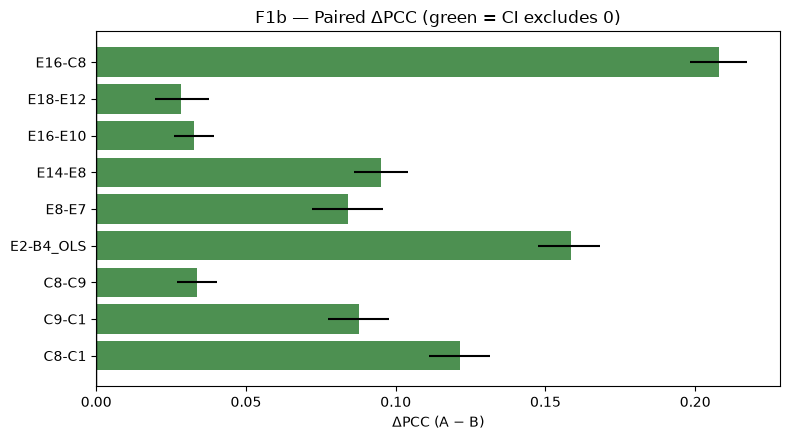

,contrast,delta,lo,hi,sig
0,C8-C1,0.121377,0.111140,0.131392,True
1,C9-C1,0.087881,0.077494,0.097881,True
2,C8-C9,0.033496,0.027049,0.040486,True
3,E2-B4_OLS,0.158368,0.147383,0.168042,True
4,E8-E7,0.083951,0.072113,0.095734,True
5,E14-E8,0.095040,0.086164,0.104092,True
6,E16-E10,0.032692,0.025941,0.039347,True
7,E18-E12,0.028224,0.019511,0.037718,True
8,E16-C8,0.208005,0.198256,0.217437,True


In [3]:
crow = []
for key, block in f1["contrasts"].items():
    d = block["pcc"]
    crow.append({"contrast": key, "delta": d["delta"], "lo": d["ci_low"], "hi": d["ci_high"], "sig": d["ci_excludes_zero"]})
cdf = pd.DataFrame(crow)
fig, ax = plt.subplots(figsize=(8, 4.5))
y = range(len(cdf))
colors = ["#2e7d32" if s else "#9e9e9e" for s in cdf["sig"]]
ax.barh(y, cdf["delta"], color=colors, alpha=0.85)
ax.errorbar(cdf["delta"], y, xerr=[cdf["delta"] - cdf["lo"], cdf["hi"] - cdf["delta"]], fmt="none", ecolor="black")
ax.axvline(0, color="black", lw=1)
ax.set_yticks(list(y))
ax.set_yticklabels(cdf["contrast"])
ax.set_xlabel("ΔPCC (A − B)")
ax.set_title("F1b — Paired ΔPCC (green = CI excludes 0)")
fig.tight_layout()
fig.savefig(OUT / "f1_paired_delta.png", dpi=120)
plt.show()
display(cdf)


In [4]:
ms = f1.get("multiseed", {})
if ms.get("skipped") or not ms.get("models"):
    print("Multi-seed not present (ran with --skip-multiseed or still running).")
else:
    for mid, block in ms["models"].items():
        print(mid, "PCC mean", round(block["pcc_mean"], 4), "std", round(block["pcc_std"], 4),
              "min", round(block["pcc_min"], 4), "max", round(block["pcc_max"], 4))
        runs = pd.DataFrame(block["runs"])
        display(runs[["seed", "pcc", "scc", "mae", "mse"]])


E2 PCC mean 0.5087 std 0.001 min 0.5073 max 0.5097


,seed,pcc,scc,mae,mse
0,0,0.509731,0.374668,0.158979,0.100042
1,1,0.507336,0.355729,0.149969,0.100618
2,2,0.509186,0.358786,0.152313,0.100449
3,3,0.509230,0.368978,0.149850,0.100290
4,4,0.508040,0.367489,0.156676,0.100360


E16 PCC mean 0.6648 std 0.0048 min 0.659 max 0.6696


,seed,pcc,scc,mae,mse
0,0,0.669533,0.429680,0.126520,0.074625
1,1,0.658951,0.414500,0.123712,0.076767
2,2,0.664290,0.425151,0.132528,0.075820
3,3,0.661598,0.416096,0.130150,0.076030
4,4,0.669620,0.433659,0.126442,0.074682


In [5]:
top = pd.read_csv(OUT / "f2_top_errors.csv")
print("F2 primary counts")
for mid, block in f2["models"].items():
    print(mid, block["counts"]["primary"])
display(top.head(20))


F2 primary counts
C8 {'other': 40025, 'T3_accent': 4516, 'T2_confusion': 2149, 'T4_context': 402, 'T5_speaker': 202, 'T1_alignment': 75}
E16 {'other': 40205, 'T3_accent': 4545, 'T2_confusion': 2149, 'T5_speaker': 186, 'T4_context': 176, 'T1_alignment': 108}


,model,utt_id,word_id,phone_id,phone,human_score,n_frames_c8,competitor_wins,speaker,any_accent,...,extreme_speaker,pred,residual,abs_err,T1_alignment,T2_confusion,T3_accent,T4_context,T5_speaker,primary_type
0,C8,96400024,2,3,T,0.0,194,False,9640,False,...,True,2.000000,2.000000,2.000000,True,True,False,False,True,T2_confusion
1,C8,96400024,4,6,N,0.0,194,False,9640,False,...,True,2.000000,2.000000,2.000000,True,True,False,False,True,T2_confusion
2,C8,96470015,5,6,N,0.0,197,False,9647,False,...,True,2.000000,2.000000,2.000000,True,True,False,False,True,T2_confusion
3,C8,96080006,2,4,D,0.0,418,False,9608,False,...,True,1.992417,1.992417,1.992417,True,True,False,False,True,T2_confusion
4,C8,96470014,0,6,M,0.0,197,False,9647,False,...,True,1.991718,1.991718,1.991718,True,True,False,False,True,T2_confusion
5,C8,14220140,5,3,D,0.0,238,False,1422,False,...,True,1.990982,1.990982,1.990982,True,True,False,False,True,T2_confusion
6,C8,14220142,4,3,L,0.0,214,True,1422,False,...,True,1.989022,1.989022,1.989022,True,True,False,False,True,T2_confusion
7,C8,96220001,6,2,W,0.0,406,True,9622,False,...,True,1.988712,1.988712,1.988712,True,True,False,False,True,T2_confusion
8,C8,96400008,8,1,T,0.0,460,False,9640,False,...,True,1.988002,1.988002,1.988002,True,True,False,False,True,T2_confusion
9,C8,96010013,6,2,D,0.0,410,False,9601,False,...,True,1.984350,1.984350,1.984350,True,True,False,False,True,T2_confusion
